# 2 Group Flux Calculator
This will be based of of previous homeworks and use code that I have written from those homeworks

In [62]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import math
import mpact_geometry, mpact_material,mpact_reader,xs_postprocessor
import sn_transport
import scipy
from mpact_material import Material
import xml.etree.cElementTree as ET

## Materials
Below we have the single group macroscopic cross sections calculated from the materials we used earlier. We should import simlar materials to the ones used in the triga for good comparisons:

The specific densities and nuclides and tempatures used in generating these cross sections are currently mostly guess/quick lookups.
Same thing with the geometries

In [63]:
# Material Macroscopic Cross Sections for one group diffusion
fuelmix_xc   = {'sigT': 5.982E-1, 'sigTr': 3.167E-1, 'D': 1/(3*3.167E-1), 'sigA': 7.381E-2, 'nusigF': 8.3874E-2, 'kapsigF': 1.18796E-12}
reflector_xc = {'sigT': 7.619E-1, 'sigTr': 1.848E-1, 'D': 1/(3*1.848E-1), 'sigA': 1.073E-3, 'nusigF': 0.0, 'kapsigF': 0.0}
steel_xc     = {'sigT': 6.705E-1, 'sigTr': 3.861E-1, 'D': 1/(3*3.861E-1), 'sigA': 4.231E-2, 'nusigF': 0.0, 'kapsigF': 0.0}
concrete_xc  = {'sigT': 5.625E-1, 'sigTr': 3.846E-1, 'D': 1/(3*3.846E-1), 'sigA': 4.674E-3, 'nusigF': 0.0, 'kapsigF': 0.0}

In [64]:
#Generate 2 Group Cross Sections from MPACT library
mpact_library = 'mpact_data_8g.fmt'
lib = mpact_reader.MPACTLibrary()
lib.load(mpact_library)

# Get nuclides
u235 = lib.find_nuclide_by_name('U-235')
u238 = lib.find_nuclide_by_name('U-238')
o16 = lib.find_nuclide_by_name('O-16')
h1 = lib.find_nuclide_by_name('H-1')
b10 = lib.find_nuclide_by_name('B-10')
b11 = lib.find_nuclide_by_name('B-11')
he4 = lib.find_nuclide_by_name('HE-4')
na23 = lib.find_nuclide_by_name('NA-23')
c12 = lib.find_nuclide_by_name('C-NAT')

# Zircaloy-4 Cladding
# =========================================================================
clad_temp    = 600.0  # K
clad_density = 6.55   # g/cm³

# Zircaloy-4: ~98.2% Zr, 1.5% Sn, 0.2% Fe, 0.1% Cr
# N_Zr = ρ * N_A / M_Zr where M_Zr ≈ 91.22 g/mol
# At 6.55 g/cm³: N_Zr ≈ 0.0432 atoms/b-cm
N_zr_total = 0.0432

zircaloy = Material("Zircaloy-4", temperature=clad_temp, density=clad_density)
zr_nat = lib.find_nuclide_by_name('ZR-NAT')

if zr_nat:
    zircaloy.add_nuclide(zr_nat, N_zr_total * 0.982)

# Add Sn and Fe if available
sn_nat = lib.find_nuclide_by_name('SN-NAT')
fe56 = lib.find_nuclide_by_name('FE-56')
if sn_nat:
    zircaloy.add_nuclide(sn_nat, N_zr_total * 0.015)
if fe56:
    zircaloy.add_nuclide(fe56, N_zr_total * 0.003)

#UO2 HAELU
########################################################################
fuel_temp = 900 # K
fuel_density = 10.4 # g/cc
N_uo2_total = 0.0232 #atom/b-cm
fuel_enrichment = 0.20 # highly enriched fuel for fast reactor
uo2 = Material('UO2', temperature=fuel_temp, density=fuel_density)
# U235 = lib.find_nuclide_by_name('U-235') These are already defined above, but you can redefine them here if you want
# U238 = lib.find_nuclide_by_name('U-238')
# O16 = lib.find_nuclide_by_name('O-16')
uo2.add_nuclide(u235, N_uo2_total * fuel_enrichment)
uo2.add_nuclide(u238, N_uo2_total * (1 - fuel_enrichment))
uo2.add_nuclide(o16, N_uo2_total * 2)  # O/U ratio of 2 in UO2

#Na Coolent
########################################################################
coolant_temp = 500 # K
coolant_density = 0.927 # g/cc
N_Na_total = 0.0243 # atom/b-cm at 0.927 g/cc
Na_coolant = Material('Na', temperature=coolant_temp, density=coolant_density)
Na_coolant.add_nuclide(na23, N_Na_total)  # Na-23 is the only stable isotope of sodium

#Graphite Reflector
########################################################################
reflector_temp = 600 # K
reflector_density = 2 # g/cc 
N_graphite_total = 0.085 # atom/b-cm at 2 g/cc for carbon
graphite = Material('Graphite', temperature=reflector_temp, density=reflector_density)
graphite.add_nuclide(c12, N_graphite_total)  # Carbon-12 is the dominant isotope in graphite

# =========================================================================
# Create Geometry
# =========================================================================
# Using reflecting BC on both sides represents infinite lattice
fuel_radius = 0.4096
gap_thickness = 0.0082
clad_thickness = 0.0572  # 0.4750 - 0.4178
pitch = 1.26
half_pitch = pitch / 2.0

pinGeom = mpact_geometry.OneDimensionalCartesianGeometryAndMesh("Fast Pin Cell")

# Mesh for pin: finer in fuel, coarser elsewhere
pinGeom.add_region(uo2, length=fuel_radius, n_cells=20, temperature=fuel_temp)
pinGeom.add_region(zircaloy, length=clad_thickness, n_cells=4, temperature=clad_temp)
pinGeom.add_region(Na_coolant, length=(half_pitch - fuel_radius - clad_thickness), n_cells=4, temperature=coolant_temp)

pinGeom.finalize()

#Mesh for coolant region: coarser mesh to speed up solution, since we're primarily interested in fuel flux
coolantGeom = mpact_geometry.OneDimensionalCartesianGeometryAndMesh("Fast Coolant Cell")
coolantGeom.add_region(Na_coolant, length=half_pitch, n_cells=4, temperature=coolant_temp)

coolantGeom.finalize()

reflectGeom = mpact_geometry.OneDimensionalCartesianGeometryAndMesh("Fast Reflector Cell")
reflectGeom.add_region(graphite, length=half_pitch, n_cells=4, temperature=reflector_temp)

reflectGeom.finalize()

#Not really sure what this will be used for
materials = {
    'fuel': uo2,
    'clad': zircaloy,
    'coolant': Na_coolant,
    'reflector': graphite
}

# =========================================================================
# Solve Transport Problem
# =========================================================================

pinSolver = sn_transport.OptimizedLDFESNTransportSolver( 
    pinGeom, 
    quadrature_order=8,      # S4 for speed
    left_bc='reflect', 
    right_bc='reflect'
)
pinSolver.tolerance = 1e-5      # Relaxed tolerance
pinSolver.max_iterations = 5000

pinSolver.solve()

coolantSolver = sn_transport.OptimizedLDFESNTransportSolver( 
    coolantGeom, 
    quadrature_order=8,      # S4 for speed
    left_bc='vacuum', 
    right_bc='vacuum'
)
coolantSolver.tolerance = 1e-5      # Relaxed tolerance
coolantSolver.max_iterations = 5000

coolantSolver.solve()

reflectSolver = sn_transport.OptimizedLDFESNTransportSolver( 
    reflectGeom, 
    quadrature_order=8,      # S4 for speed
    left_bc='vacuum', 
    right_bc='vacuum'
)
reflectSolver.tolerance = 1e-5      # Relaxed tolerance
reflectSolver.max_iterations = 5000

reflectSolver.solve()

Loading MPACT library: mpact_data_8g.fmt
  Chi spectrum: [5.843493e-01 4.153784e-01 2.723212e-04 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00]
Successfully loaded 295 nuclides
  Energy groups: 8
  Energy bounds: 2.00e+07 eV to 1.00e-05 eV
Added region 0: UO2, x=[0.0000, 0.4096] cm, 20 cells, T=900.0 K
Added region 1: Zircaloy-4, x=[0.4096, 0.4668] cm, 4 cells, T=600.0 K
Added region 2: Na, x=[0.4668, 0.6300] cm, 4 cells, T=500.0 K

Finalizing geometry: Fast Pin Cell

Region 0: UO2
  Position: [0.0000, 0.4096] cm
  Cells: 20, Width: 0.020480 cm

Region 1: Zircaloy-4
  Position: [0.4096, 0.4668] cm
  Cells: 4, Width: 0.014300 cm

Region 2: Na
  Position: [0.4668, 0.6300] cm
  Cells: 4, Width: 0.040800 cm

Geometry finalized:
  Total length: 0.6300 cm
  Total cells: 28
  Total nodes: 29
  Regions: 3
Added region 0: Na, x=[0.0000, 0.6300] cm, 4 cells, T=500.0 K

Finalizing geometry: Fast Coolant Cell

Region 0: Na
  Position: [0.0000, 0.6300] cm
  Cells: 4, Width: 0.15

In [65]:
#get 2 group cross sections from solver
pin_post_processor = xs_postprocessor.CrossSectionPostProcessor(pinSolver)
pin_xs_2g = pin_post_processor.collapse_to_2group(group_boundaries=[2,8])
coolant_post_processor = xs_postprocessor.CrossSectionPostProcessor(coolantSolver)
coolant_xs_2g = coolant_post_processor.collapse_to_2group(group_boundaries=[2,8])
reflect_post_processor = xs_postprocessor.CrossSectionPostProcessor(reflectSolver)
reflect_xs_2g = reflect_post_processor.collapse_to_2group(group_boundaries=[2,8])



Cross-Section Post-Processor initialized
  Cells: 28, Groups: 8
  Total volume: 0.630000 cm

Cross-Section Post-Processor initialized
  Cells: 4, Groups: 8
  Total volume: 0.630000 cm

Cross-Section Post-Processor initialized
  Cells: 4, Groups: 8
  Total volume: 0.630000 cm


In [66]:
#aggregate into a single crossection dictionary objects for use in diffusion solver
# note the inclusion fo the scatter matrix, which will be used to build the up and down scatter matrices for the two group diffusion solver
fuel_xs = {'sigT':    pin_xs_2g.sigma_t, 
                'sigTr':   pin_xs_2g.sigma_tr, 
                'D':       1/(3*pin_xs_2g.sigma_tr), 
                'sigA':    pin_xs_2g.sigma_a, 
                'nusigF':  pin_xs_2g.nu_sigma_f, 
                'kapsigF': pin_xs_2g.kappa_sigma_f,
                'sigSmatrix': pin_xs_2g.scatter_matrix}
coolant_xs = {'sigT':    coolant_xs_2g.sigma_t, 
                'sigTr':   coolant_xs_2g.sigma_tr, 
                'D':       1/(3*coolant_xs_2g.sigma_tr), 
                'sigA':    coolant_xs_2g.sigma_a, 
                'nusigF':  coolant_xs_2g.nu_sigma_f, 
                'kapsigF': coolant_xs_2g.kappa_sigma_f,
                'sigSmatrix': coolant_xs_2g.scatter_matrix}
reflect_xs = {'sigT':    reflect_xs_2g.sigma_t, 
                'sigTr':   reflect_xs_2g.sigma_tr,
                'D':       1/(3*reflect_xs_2g.sigma_tr), 
                'sigA':    reflect_xs_2g.sigma_a, 
                'nusigF':  reflect_xs_2g.nu_sigma_f, 
                'kapsigF': reflect_xs_2g.kappa_sigma_f,
                'sigSmatrix': reflect_xs_2g.scatter_matrix}

## Modify one group diffusion code for 2 group
Need to add in cross terms for group hopping. The way we will do this invlves incorperating the old 1D diffusion matrcies into a larger  2NX2N matrix that includes the cross terms for up and down scatter.


In [67]:
# These are the 1D diffusion equations for a single energy group modified to take a group nummber as an input. I will use these to build the M and F matrices for the eigenvalue problem.
# I will reduce outside dependecies by inclding dx in the function inputs
# dx is the cell width, which is uniform
# space is a list of dictionaries, where each dictionary contains the cross sections for that cell
dx = 0.1
def removal_xs(cell, group): # have to modify all sigA terms from 1 group to be removal terms becasue we need to include loss from scattering out
    if group == 0:   # fast group
        return cell['sigA'][0] + cell['sigSmatrix'][0][1]
    elif group == 1: # thermal group
        return cell['sigA'][1] + cell['sigSmatrix'][1][0] 

def alpha(C,L,group, dx):
    """ 
    C is current cell
    L is left cell
    """
    return (dx/2*(1/C['D'][group]+1/L['D'][group]))**-1

def gamma(C,R,group, dx):
    """R is right cell"""
    return (dx/2*(1/C['D'][group]+1/R['D'][group]))**-1

def beta(C, L, R, group, dx):
    return removal_xs(C,group)*dx + alpha(C,L,group,dx) + gamma(C,R,group,dx)

def build_M(space, group, dx, left_bc='vacuum', right_bc='vacuum'):
    dim = int(len(space))
    M = np.zeros([dim,dim])
    if left_bc == 'vacuum':
        M[0][0]   = removal_xs(space[0], group)*dx + alpha(space[1],space[0],group,dx) + space[0]['D'][group]/(dx/2 + 0.7104/space[0]['sigTr'][group])
        M[0][1] =  -gamma(space[1],space[0],group,dx)

    elif left_bc == 'reflector':
        M[0][0] =  removal_xs(space[0], group)*dx + 0 + gamma(space[0],space[1],group,dx)
        M[0][1] = -gamma(space[1],space[0],group,dx)
    else:
        raise ValueError("left_bc must be 'vacuum' or 'reflector'") 
    
    if right_bc == 'vacuum':
        M[dim-1][dim-2] =  -alpha(space[-2],space[-1],group,dx)
        M[dim-1][dim-1]   = removal_xs(space[-1], group)*dx + alpha(space[-2],space[-1],group,dx) + space[-1]['D'][group]/(dx/2 + 0.7104/space[-1]['sigTr'][group])
    elif right_bc == 'reflector':
        M[dim-1][dim-2] =  -alpha(space[-2],space[-1],group,dx)
        M[dim-1][dim-1]   = removal_xs(space[-1], group)*dx + 0 + gamma(space[-1],space[-2],group,dx)
    else:
        raise ValueError("right_bc must be 'vacuum' or 'reflector'") 
    
    for i in range(1,dim-1):
        M[i][i-1] = -alpha(space[i],space[i-1],group,dx)
        M[i][i]   =  beta(space[i],space[i-1],space[i+1],group,dx)
        M[i][i+1] = -gamma(space[i],space[i+1],group,dx)
    return M

def build_F(space, group, dx):
    dim = int(len(space))
    F = np.zeros([dim,dim])
    for loc,region in enumerate(space):
        if region['nusigF'][group] > 0:
            F[loc][loc] = region['nusigF'][group]*dx
    return F



## Cross Terms 
Now we need to build the cross term matrixes that will be on the non diagonal enteries of the 2 group diffusion matrix
M_2g =  M11, M12
        M21, M22
We already have M11 and M22 for each group which are just the 1 group diffussion Matrices
The Cross term matrices will simply be filled the down or up scatter terms respectivly for M12 and M21
Luckily the corossection generation code has already nicely provided us with these cross terms:

In [68]:
def down_up_scatter_matrixes(space, dx):
    dim = int(len(space))
    US = np.zeros([dim,dim])
    DS = np.zeros([dim,dim])
    for i in range(dim):
        DS[i][i] = -space[i]['sigSmatrix'][0][1]*dx #these get the cross terms from group 1 to group 2
        US[i][i] = -space[i]['sigSmatrix'][1][0]*dx #these get the cross terms from group 2 to group 1
    return DS, US

#Bring in power iteration code for eigenvalue problem:
# This is unchagned because the math is actually the exact same as the one group case, we just need to make sure to use the correct M and F matrices for each group, which we can do by passing in the group number as an argument to the build_M and build_F functions. We also need to make sure to use the correct flux guess for each group, which we can do by initializing the flux_guess array to be twice the length of the space array, with the first half being the guess for group 1 and the second half being the guess for group 2. The rest of the power iteration code should work without modification.
def calculate_flux(M : np.ndarray, F : np.ndarray, dx : float, flux_guess : np.ndarray, k_guess : float, ErrorThreshold : float):
    inverse_M = np.linalg.inv(M)
    while True:
        new_flux_guess = (1/k_guess) * (inverse_M @ (F @ flux_guess))
        new_k = k_guess * sum(F @ new_flux_guess) / sum(F @ flux_guess)

        if abs(new_k - k_guess) < ErrorThreshold:
            print(f"Converged to keff = {new_k:.5f}")
            flux_output = new_flux_guess / np.linalg.norm(new_flux_guess)
            k_output = new_k
            break
        k_guess = new_k
        flux_guess = new_flux_guess / np.linalg.norm(new_flux_guess)
    return flux_output, k_output

## Putting it all together
Now we assemble the matrices together and solve using the same method as before


Converged to keff = 1.21913


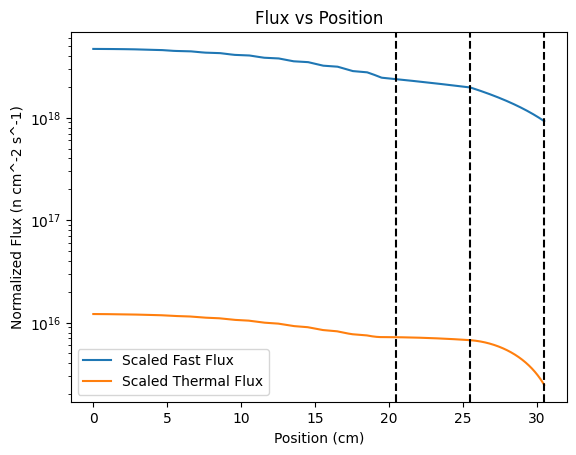

Flux At Core Center (Fast Group):  3.295179520959775e+18
Flux At Core Center (Thermal Group):  8595148676788357.0


In [69]:
#Define the mesh size
dx = 0.01
# Define the reactor as a symetrical 1D system
pinSize = 1 # cm
coolantChannelSize = 1 # cm
pinNumber = 10 # number of pins on each side of core (cm)
coolantPoolSize = 5 # cm
reflectorSize = 5 # cm 

coreBoundry = coolantChannelSize/2+(pinSize+coolantChannelSize)*pinNumber
poolBoundry = coreBoundry + coolantPoolSize
reflectorBoundry = poolBoundry + reflectorSize

space = ([coolant_xs] * int(coolantChannelSize/(2*dx)) + # Centered on coolant channel
         ([fuel_xs] * int(pinSize/dx) + [coolant_xs] * int(coolantChannelSize/(dx))) * pinNumber + # Repeat for each pin and coolant channel
         [coolant_xs] * int(coolantPoolSize/dx) + # small coolant pool
         [reflect_xs] * int(reflectorSize/dx)) # Reflector on the outside



fast_chi = 1 # all fissions go to group 1, so the chi for group 2 is zero

M11 = build_M(space, 0, dx, left_bc='reflector', right_bc='vacuum')
F11 = build_F(space, 0, dx) * fast_chi
M22 = build_M(space, 1, dx, left_bc='reflector', right_bc='vacuum')
F22 = build_F(space, 1, dx) * (1 - fast_chi)# This should be zero since there are no fissions in group 2, but I'm including it for completeness

M21, M12 = down_up_scatter_matrixes(space, dx)

nusigF2 = np.array([r['nusigF'][1] for r in space])
F12 = np.diag(nusigF2)*fast_chi * dx
F21 = np.diag(nusigF2)*(1 - fast_chi) * dx


M = np.block([[M11, M12], 
              [M21, M22]])
F = np.block([[F11, F12],
              [F21, F22]])


power = 10e6 

flux_guess = np.array([1]*(2*len(space))) # needs to be 2 times the length of space since we have 2 groups
k_guess = 1.0
ErrorThreshold = 1e-6

flux_output, k_output = calculate_flux(M,F,dx,flux_guess,k_guess,ErrorThreshold)

N = len(space)

phi1 = flux_output[:N]
phi2 = flux_output[N:]

# To:
kapsigF1 = np.array([r['kapsigF'][0] for r in space]) * 1.6e-13 #These multipliers are convirting to J from MeV
kapsigF2 = np.array([r['kapsigF'][1] for r in space]) * 1.6e-13 #for some reason kapsigF is in MeV


current_power = np.sum((kapsigF1 * phi1 + kapsigF2 * phi2) * dx)
scale_factor = power / current_power
phi1_scaled = phi1 * scale_factor
phi2_scaled = phi2 * scale_factor

position = np.linspace(0, N * dx, len(space))

plt.plot(position, phi1_scaled, label='Scaled Fast Flux')
plt.plot(position, phi2_scaled, label='Scaled Thermal Flux')
plt.axvline(x=coreBoundry, color='black', linestyle='--')
plt.axvline(x=poolBoundry, color='black', linestyle='--')
plt.axvline(x=reflectorBoundry, color='black', linestyle='--')
plt.xlabel('Position (cm)')
plt.ylabel('Normalized Flux (n cm^-2 s^-1)')
plt.title('Flux vs Position')
plt.legend()
plt.yscale('log')
plt.show()

print("Flux At Core Center (Fast Group): ", phi1_scaled[int(len(space)/2)])
print("Flux At Core Center (Thermal Group): ", phi2_scaled[int(len(space)/2)])

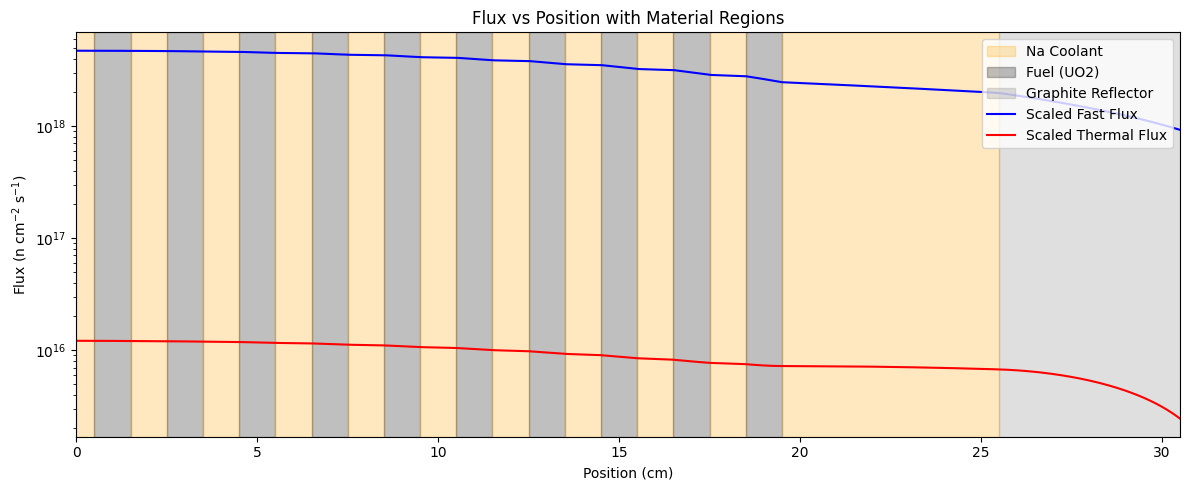

In [70]:
# Flux profiles with material region coloring
fig, ax = plt.subplots(figsize=(12, 5))

# Draw colored material spans in the background
start_idx = 0
current_mat = space[0]
for i in range(1, len(space) + 1):
    if i == len(space) or space[i] is not current_mat:
        x_start = position[start_idx]
        x_end = position[i - 1] + dx
        if current_mat is fuel_xs:
            color, label = 'black', 'Fuel (UO2)'
        elif current_mat is coolant_xs:
            color, label = 'orange', 'Na Coolant'
        else:
            color, label = 'gray', 'Graphite Reflector'
        ax.axvspan(x_start, x_end, color=color, alpha=0.25, label=label)
        if i < len(space):
            current_mat = space[i]
            start_idx = i

# Plot flux on top
ax.plot(position, phi1_scaled, color='blue', label='Scaled Fast Flux')
ax.plot(position, phi2_scaled, color='red', label='Scaled Thermal Flux')

# Deduplicate legend (material spans repeat; flux lines are unique)
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), loc='upper right')

ax.set_yscale('log')
ax.set_xlabel('Position (cm)')
ax.set_ylabel('Flux (n cm$^{-2}$ s$^{-1}$)')
ax.set_title('Flux vs Position with Material Regions')
ax.set_xlim(position[0], position[-1] + dx)
plt.tight_layout()
plt.show()

In [71]:
print("Fuel thermal XS:", pin_xs_2g.sigma_tr, pin_xs_2g.scatter_matrix)
print("Coolant thermal XS:", coolant_xs_2g.sigma_tr, coolant_xs_2g.scatter_matrix)
print("Reflector thermal XS:", reflect_xs_2g.sigma_tr, reflect_xs_2g.scatter_matrix)


Fuel thermal XS: [0.25545258 0.79101641] [[0.24843642 0.00089429]
 [0.         0.44323962]]
Coolant thermal XS: [0.06210767 0.35477726] [[6.20972728e-02 1.04075537e-05]
 [0.00000000e+00 3.54777281e-01]]
Reflector thermal XS: [0.1607752  0.40253672] [[1.60635770e-01 1.39488266e-04]
 [0.00000000e+00 4.02536796e-01]]
